# HW2 — Regression and Classification: Error Analysis

**Dataset:** Used Cars (Craigslist Cars/Trucks, `austinreese/craigslist-carstrucks-data`)

This notebook is organized into three parts, matching the assignment rubric:

- **Part 1 — Regression Error Analysis:** residuals, feature-vs-error patterns, extreme errors, error statistics.
- **Part 2 — Regression Models:** Linear Regression, Decision Tree, Random Forest, XGBoost, SVR (bonus), all evaluated with 5-fold cross-validation.
- **Part 3 — Classification Models & Error Analysis:** Logistic Regression & Random Forest Classifier predicting transmission type, with confusion-matrix, probability-based, and threshold-sensitivity error analysis.


## 0. Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kurtosis, skew
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_SEED = 42


## 1. Data Loading and Preprocessing

In [2]:
used_cars_raw = pd.read_csv("archive/vehicles.csv")
print("Raw shape:", used_cars_raw.shape)
used_cars_raw.head()


Raw shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [3]:
missing_value_counts = used_cars_raw.isna().sum().sort_values(ascending=False)
missing_value_fraction = (missing_value_counts / len(used_cars_raw)).round(3)
pd.DataFrame({"missing_count": missing_value_counts, "missing_fraction": missing_value_fraction}).head(15)


,missing_count,missing_fraction
county,426880,1.000
size,306361,0.718
cylinders,177678,0.416
condition,174104,0.408
VIN,161042,0.377
drive,130567,0.306
paint_color,130203,0.305
type,92858,0.218
manufacturer,17646,0.041
title_status,8242,0.019


**Cleaning plan:**
- Drop identifier / free-text / URL columns that carry no modeling signal (`id`, `url`, `region_url`, `VIN`, `image_url`, `description`, `county`, `lat`, `long`, `posting_date`, `model`, `size`).
  `model` and `region` are dropped for having too many rare categories relative to dataset size (thousands of unique values), which would blow up one-hot dimensionality without adding robust signal.
- Keep rows with a valid, realistic `price` (\$500–\$100,000 — removes placeholder \$0/\$1 listings and unrealistic outliers), a valid `year` (1990–2022), and a valid `odometer` (0–300,000 miles).
- Remaining missing values in categorical columns are imputed with `"missing"` (kept as its own informative category) and numeric columns with the median, inside the modeling pipeline (Section 4) — not by dropping rows — to preserve sample size.


In [4]:
columns_to_drop = [
    "id", "url", "region_url", "VIN", "image_url", "description",
    "county", "lat", "long", "posting_date", "model", "size", "region",
]
used_cars_cleaned = used_cars_raw.drop(columns=columns_to_drop)

used_cars_cleaned = used_cars_cleaned[
    used_cars_cleaned["price"].between(500, 100_000)
    & used_cars_cleaned["year"].between(1990, 2022)
    & used_cars_cleaned["odometer"].between(0, 300_000)
].dropna(subset=["price", "year", "odometer", "transmission"])

print("Cleaned shape:", used_cars_cleaned.shape)
used_cars_cleaned.head()


Cleaned shape: (365317, 13)


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state
27,33590,2014.0,gmc,good,8 cylinders,gas,57923.0,clean,other,NaN,pickup,white,al
28,22590,2010.0,chevrolet,good,8 cylinders,gas,71229.0,clean,other,NaN,pickup,blue,al
29,39590,2020.0,chevrolet,good,8 cylinders,gas,19160.0,clean,other,NaN,pickup,red,al
30,30990,2017.0,toyota,good,8 cylinders,gas,41124.0,clean,other,NaN,pickup,red,al
31,15000,2013.0,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al


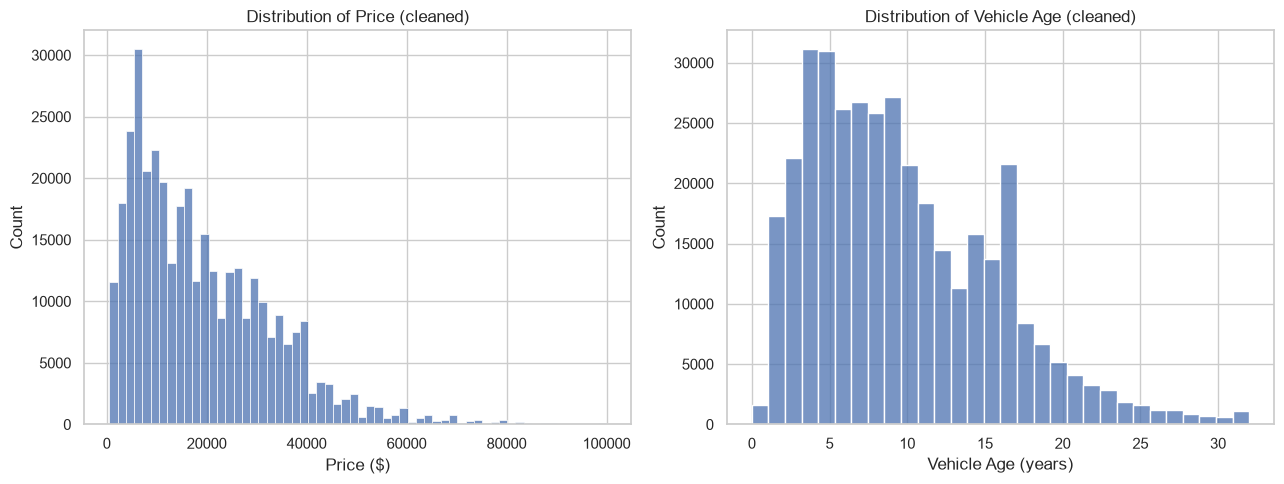

In [5]:
reference_year = int(used_cars_cleaned["year"].max())
used_cars_cleaned["vehicle_age"] = reference_year - used_cars_cleaned["year"]

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(used_cars_cleaned["price"], bins=60, ax=axes[0])
axes[0].set_title("Distribution of Price (cleaned)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

sns.histplot(used_cars_cleaned["vehicle_age"], bins=30, ax=axes[1])
axes[1].set_title("Distribution of Vehicle Age (cleaned)")
axes[1].set_xlabel("Vehicle Age (years)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


## 2. Sampling and Target Definition

**Why we sample:** the cleaned dataset still has several hundred thousand rows. Running 5-fold
cross-validation across five regression models (including `SVR`, whose training cost scales
roughly quadratically-to-cubically with sample size) and two classifiers with a full threshold
sweep on the full data would take a very long time without materially changing the qualitative
error-analysis conclusions for a homework-scale study. We therefore draw a fixed random sample
for modeling and clearly report both the original and sampled sizes below.


In [6]:
MAIN_SAMPLE_SIZE = 12_000
SVR_SAMPLE_SIZE = 3_000  # SVR is trained on a smaller sub-sample for tractability (bonus model)

used_cars_sampled = used_cars_cleaned.sample(
    n=min(MAIN_SAMPLE_SIZE, len(used_cars_cleaned)), random_state=RANDOM_SEED
).reset_index(drop=True)

print(f"Original cleaned rows: {len(used_cars_cleaned):,}")
print(f"Modeling sample rows:  {len(used_cars_sampled):,}")


Original cleaned rows: 365,317
Modeling sample rows:  12,000


In [7]:
# Regression target: continuous price
regression_target_column = "price"

# Classification target: binary transmission type (automatic vs. manual), 'other' dropped
used_cars_classification = used_cars_sampled[used_cars_sampled["transmission"] != "other"].copy()
used_cars_classification["transmission_is_automatic"] = (
    used_cars_classification["transmission"] == "automatic"
).astype(int)

print(used_cars_classification["transmission_is_automatic"].value_counts(normalize=True).round(3))


transmission_is_automatic
1    0.939
0    0.061
Name: proportion, dtype: float64


In [8]:
base_numeric_features = ["vehicle_age", "odometer"]
base_categorical_features = [
    "manufacturer", "condition", "cylinders", "fuel",
    "title_status", "drive", "type", "paint_color", "state",
]

regression_numeric_features = base_numeric_features
regression_categorical_features = base_categorical_features + ["transmission"]

classification_numeric_features = base_numeric_features + ["price"]
classification_categorical_features = base_categorical_features

features_regression = used_cars_sampled[regression_numeric_features + regression_categorical_features]
target_regression = used_cars_sampled[regression_target_column]

features_classification = used_cars_classification[
    classification_numeric_features + classification_categorical_features
]
target_classification = used_cars_classification["transmission_is_automatic"]

print("Regression feature matrix:", features_regression.shape)
print("Classification feature matrix:", features_classification.shape)


Regression feature matrix: (12000, 12)
Classification feature matrix: (10040, 12)


## 3. Cross-Validation Strategy

### Justification for k = 5

- **Dataset size:** the modeling sample has 12,000 rows (transmission classification ~similar,
  minus the small `other` category). With k = 5, every fold's validation split still holds out
  ~2,400 observations — large enough for stable, low-variance performance estimates — while every
  training split keeps ~9,600 rows, comfortably enough for tree ensembles and linear models to
  fit reliably.
- **Computational complexity:** this notebook trains 5 regression models and 2 classification
  models, several of which (Random Forest, XGBoost, SVR) are non-trivial to fit. k = 10 or
  leave-one-out would roughly double or explode training cost for a marginal reduction in
  estimator variance; k = 5 is the standard, well-established compromise in the literature for
  moderate-size tabular datasets like this one.
- **Bias–variance trade-off:** a small k (e.g., k = 2 or 3) yields training folds that are a much
  smaller fraction of the data, inflating the *bias* of the performance estimate (models are
  undertrained relative to what full-data training would achieve). A large k (e.g., k = 20 or
  LOOCV) reduces that bias but makes the *variance* of the estimate across folds worse (each
  fold's validation set is tiny and noisy) and multiplies runtime. k = 5 keeps train folds large
  (80% of data) while still averaging over 5 independent validation splits, giving a
  low-bias, reasonably low-variance estimate at moderate compute cost.


In [9]:
kfold_regression = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
stratified_kfold_classification = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


## 4. Preprocessing Pipeline

In [10]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", max_categories=20)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])


## 5. Part 2 — Regression Models

In [11]:
regression_preprocessor = build_preprocessor(regression_numeric_features, regression_categorical_features)

regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_SEED),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=RANDOM_SEED),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=RANDOM_SEED),
}

regression_scoring = {"mse": "neg_mean_squared_error", "r2": "r2"}
regression_results = []

for model_name, regressor in regression_models.items():
    pipeline = Pipeline([("preprocessor", regression_preprocessor), ("model", regressor)])
    cv_scores = cross_validate(
        pipeline, features_regression, target_regression,
        cv=kfold_regression, scoring=regression_scoring, n_jobs=-1,
    )
    mse_scores = -cv_scores["test_mse"]
    regression_results.append({
        "model": model_name,
        "mse_mean": mse_scores.mean(),
        "mse_std": mse_scores.std(),
        "rmse_mean": np.sqrt(mse_scores).mean(),
        "rmse_std": np.sqrt(mse_scores).std(),
        "r2_mean": cv_scores["test_r2"].mean(),
        "r2_std": cv_scores["test_r2"].std(),
    })
    print(f"Done: {model_name}")


Done: Linear Regression


Done: Decision Tree


Done: Random Forest


Done: XGBoost


In [12]:
# Bonus model: SVR, trained on a smaller sub-sample for computational tractability (see Section 2)
svr_sample = used_cars_sampled.sample(n=min(SVR_SAMPLE_SIZE, len(used_cars_sampled)), random_state=RANDOM_SEED)
svr_features = svr_sample[regression_numeric_features + regression_categorical_features]
svr_target = svr_sample[regression_target_column]

svr_pipeline = Pipeline([
    ("preprocessor", build_preprocessor(regression_numeric_features, regression_categorical_features)),
    ("model", SVR(kernel="rbf", C=10.0)),
])
svr_cv_scores = cross_validate(
    svr_pipeline, svr_features, svr_target,
    cv=kfold_regression, scoring=regression_scoring, n_jobs=-1,
)
svr_mse_scores = -svr_cv_scores["test_mse"]
regression_results.append({
    "model": "SVR (bonus, n=3,000)",
    "mse_mean": svr_mse_scores.mean(),
    "mse_std": svr_mse_scores.std(),
    "rmse_mean": np.sqrt(svr_mse_scores).mean(),
    "rmse_std": np.sqrt(svr_mse_scores).std(),
    "r2_mean": svr_cv_scores["test_r2"].mean(),
    "r2_std": svr_cv_scores["test_r2"].std(),
})
print("Done: SVR")


Done: SVR


In [13]:
regression_results_df = pd.DataFrame(regression_results).sort_values("rmse_mean").reset_index(drop=True)
regression_results_df


,model,mse_mean,mse_std,rmse_mean,rmse_std,r2_mean,r2_std
0,XGBoost,4.526365e+07,3.919830e+06,6721.564431,290.203375,0.779017,0.017594
1,Random Forest,4.857066e+07,4.933274e+06,6960.319811,352.993737,0.762935,0.022143
2,Linear Regression,6.672397e+07,5.048903e+06,8162.710656,306.799264,0.674268,0.021365
3,Decision Tree,7.129717e+07,2.597763e+06,8442.361448,153.948822,0.651810,0.009353
4,"SVR (bonus, n=3,000)",2.112753e+08,1.388661e+07,14527.601811,473.326635,0.015574,0.024583


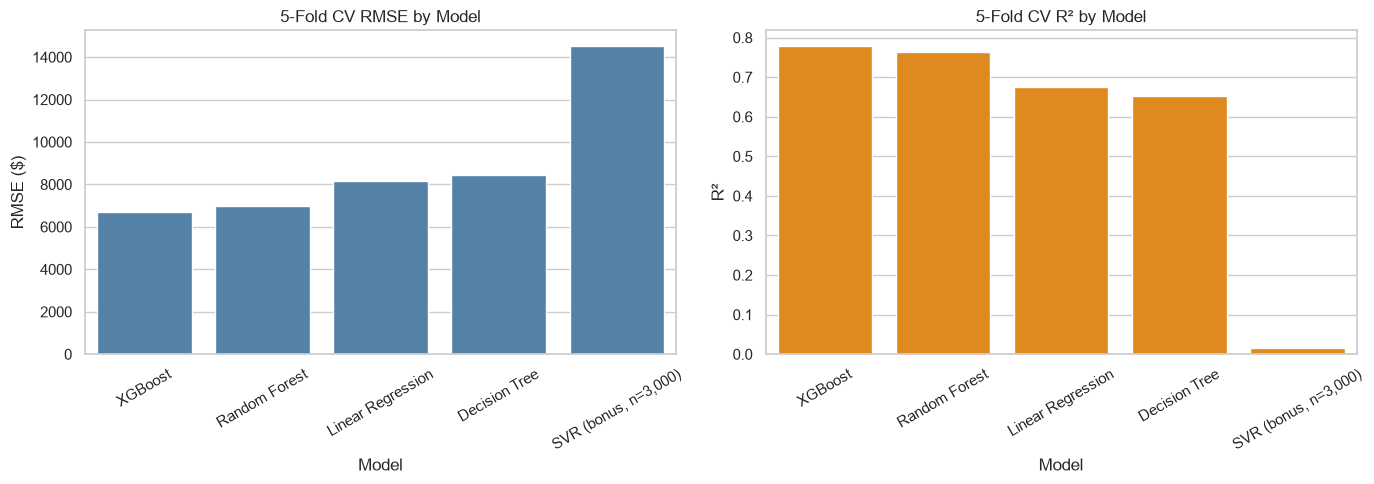

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=regression_results_df, x="model", y="rmse_mean", ax=axes[0], color="steelblue")
axes[0].set_title("5-Fold CV RMSE by Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("RMSE ($)")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=regression_results_df, x="model", y="r2_mean", ax=axes[1], color="darkorange")
axes[1].set_title("5-Fold CV R\u00b2 by Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("R\u00b2")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### Discussion

*(Address here: relative model performance across MSE/RMSE/R²; how well linearity/independence/
homoskedasticity assumptions are satisfied; bias–variance differences between the models;
sensitivity to outliers and noise; scenarios where linear models fail and why; where tree-based
models have an advantage; the interpretability-vs-performance trade-off; your preferred model
with justification; what you learned from the modeling stage.)*


## 6. Part 1 — Regression Error Analysis

We use the best-performing regression model from Section 5 (lowest cross-validated RMSE, excluding
the bonus SVR model which was trained on a different sub-sample) and compute **out-of-fold**
predictions with `cross_val_predict` under the same 5-fold split — every prediction is made by a
model that never saw that row during training, giving unbiased residuals for error analysis.


In [15]:
best_model_name = (
    regression_results_df[regression_results_df["model"] != "SVR (bonus, n=3,000)"]
    .iloc[0]["model"]
)
print("Best model for error analysis:", best_model_name)

best_regression_pipeline = Pipeline([
    ("preprocessor", regression_preprocessor),
    ("model", regression_models[best_model_name]),
])

oof_predictions_price = cross_val_predict(
    best_regression_pipeline, features_regression, target_regression,
    cv=kfold_regression, n_jobs=-1,
)
residuals_price = target_regression.values - oof_predictions_price


Best model for error analysis: XGBoost


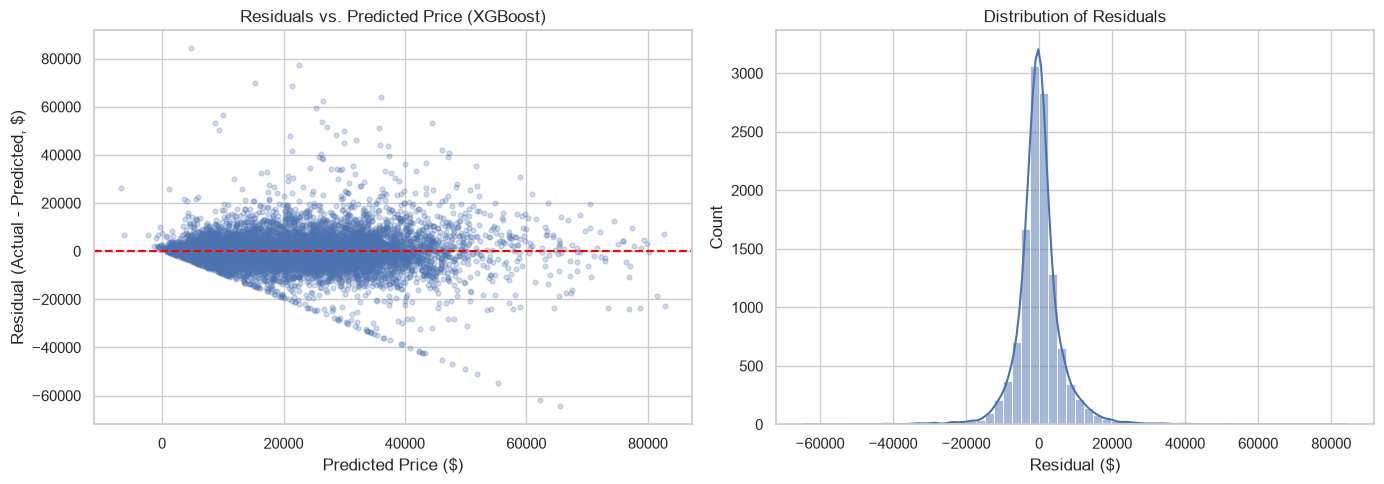

In [16]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(oof_predictions_price, residuals_price, alpha=0.25, s=12)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title(f"Residuals vs. Predicted Price ({best_model_name})")
axes[0].set_xlabel("Predicted Price ($)")
axes[0].set_ylabel("Residual (Actual - Predicted, $)")

sns.histplot(residuals_price, bins=60, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


*(Address here: are residuals centered around zero? any systematic pattern (e.g., funnel shape
indicating heteroscedasticity)? is there a vehicle sector/segment more prone to high error, and
why might that be?)*


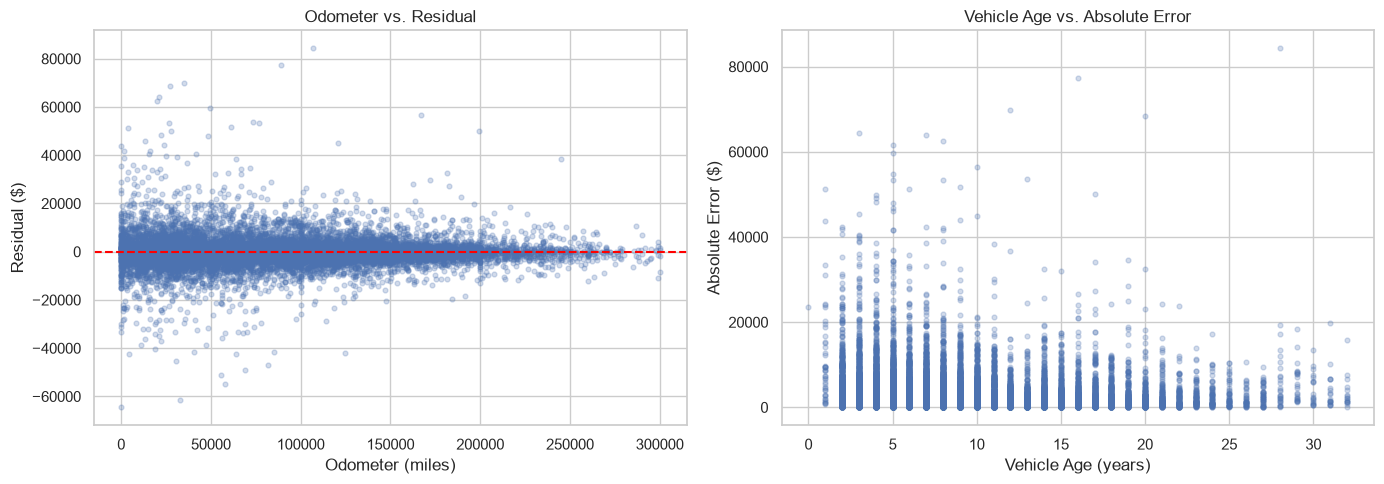

In [17]:
absolute_errors_price = np.abs(residuals_price)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(used_cars_sampled["odometer"], residuals_price, alpha=0.25, s=12)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Odometer vs. Residual")
axes[0].set_xlabel("Odometer (miles)")
axes[0].set_ylabel("Residual ($)")

axes[1].scatter(used_cars_sampled["vehicle_age"], absolute_errors_price, alpha=0.25, s=12)
axes[1].set_title("Vehicle Age vs. Absolute Error")
axes[1].set_xlabel("Vehicle Age (years)")
axes[1].set_ylabel("Absolute Error ($)")
plt.tight_layout()
plt.show()


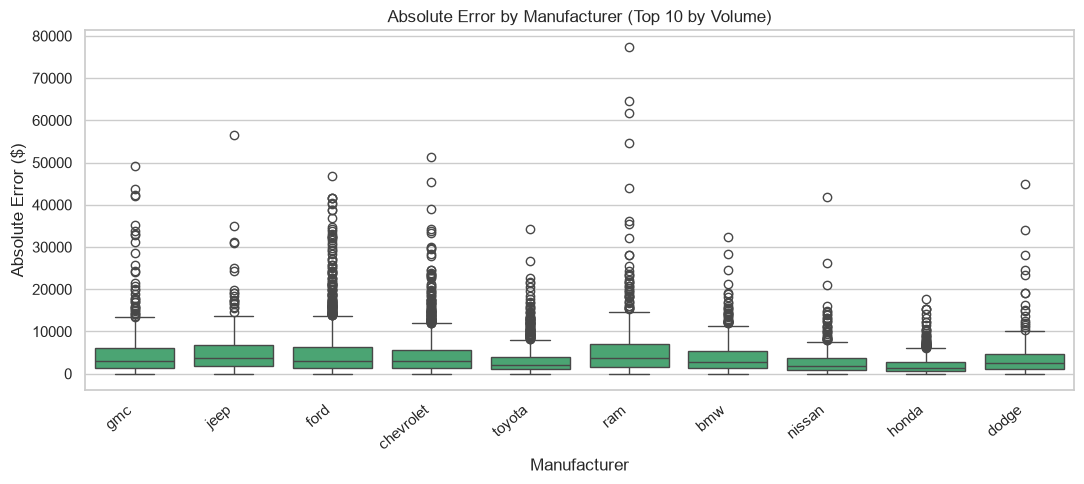

In [18]:
manufacturer_error_df = used_cars_sampled.assign(absolute_error=absolute_errors_price)
top_manufacturers = manufacturer_error_df["manufacturer"].value_counts().head(10).index
manufacturer_error_subset = manufacturer_error_df[manufacturer_error_df["manufacturer"].isin(top_manufacturers)]

plt.figure(figsize=(11, 5))
sns.boxplot(data=manufacturer_error_subset, x="manufacturer", y="absolute_error", color="mediumseagreen")
plt.title("Absolute Error by Manufacturer (Top 10 by Volume)")
plt.xlabel("Manufacturer")
plt.ylabel("Absolute Error ($)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


In [19]:
extreme_error_threshold = np.percentile(absolute_errors_price, 95)
extreme_error_mask = absolute_errors_price >= extreme_error_threshold

extreme_error_cases = used_cars_sampled.loc[extreme_error_mask].copy()
extreme_error_cases["predicted_price"] = oof_predictions_price[extreme_error_mask]
extreme_error_cases["residual"] = residuals_price[extreme_error_mask]
extreme_error_cases["absolute_error"] = absolute_errors_price[extreme_error_mask]

print(f"Top 5% extreme errors: {extreme_error_mask.sum()} of {len(absolute_errors_price)} rows")
print(f"Absolute error threshold (95th percentile): ${extreme_error_threshold:,.0f}")

extreme_error_cases.sort_values("absolute_error", ascending=False)[
    ["manufacturer", "condition", "vehicle_age", "odometer", "price", "predicted_price", "residual", "absolute_error"]
].head(20)


Top 5% extreme errors: 600 of 12000 rows
Absolute error threshold (95th percentile): $12,781


,manufacturer,condition,vehicle_age,odometer,price,predicted_price,residual,absolute_error
3682,mercedes-benz,like new,28.0,107000.0,89000,4718.533691,84281.466309,84281.466309
7702,ram,NaN,16.0,89000.0,100000,22579.445312,77420.554688,77420.554688
11517,NaN,NaN,12.0,35000.0,85000,15225.065430,69774.934570,69774.934570
5936,ferrari,NaN,20.0,27110.0,89995,21469.335938,68525.664062,68525.664062
4493,ram,excellent,3.0,24.0,1029,65552.640625,-64523.640625,64523.640625
3722,mercedes-benz,NaN,7.0,21107.0,99995,36059.253906,63935.746094,63935.746094
6477,porsche,NaN,8.0,20000.0,89000,26522.123047,62477.876953,62477.876953
6327,ram,NaN,5.0,32619.0,563,62191.792969,-61628.792969,61628.792969
2770,porsche,excellent,5.0,49500.0,85000,25347.357422,59652.642578,59652.642578
9206,jeep,NaN,10.0,167000.0,66500,10012.676758,56487.323242,56487.323242


*(Address here: for these extreme-error cases, do they look like data quality issues — e.g.
implausible price/odometer combinations — model limitations, or genuinely rare/exceptional
vehicles? Look at the table above for patterns.)*


In [20]:
mean_absolute_error_price = absolute_errors_price.mean()
std_residuals_price = residuals_price.std()
skewness_residuals_price = skew(residuals_price)
kurtosis_residuals_price = kurtosis(residuals_price)

error_statistics_summary = pd.DataFrame({
    "statistic": ["MAE", "Std. Dev. of Residuals", "Skewness", "Excess Kurtosis"],
    "value": [mean_absolute_error_price, std_residuals_price, skewness_residuals_price, kurtosis_residuals_price],
})
error_statistics_summary


,statistic,value
0,MAE,4127.771939
1,Std. Dev. of Residuals,6727.826153
2,Skewness,0.969277
3,Excess Kurtosis,17.638643


*(Interpretation: heavy tails (high kurtosis) may indicate instability / a subset of hard-to-predict
cases; non-zero skewness may indicate systematic bias in one direction.)*

### Discussion

*(Free space for your Part 1 write-up.)*


## 7. Part 3 — Classification Models

In [21]:
classification_preprocessor = build_preprocessor(classification_numeric_features, classification_categorical_features)

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=300, max_depth=12, n_jobs=-1, random_state=RANDOM_SEED
    ),
}

classification_scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
classification_results = []

for model_name, classifier in classification_models.items():
    pipeline = Pipeline([("preprocessor", classification_preprocessor), ("model", classifier)])
    cv_scores = cross_validate(
        pipeline, features_classification, target_classification,
        cv=stratified_kfold_classification, scoring=classification_scoring, n_jobs=-1,
    )
    classification_results.append({
        "model": model_name,
        "accuracy_mean": cv_scores["test_accuracy"].mean(),
        "precision_mean": cv_scores["test_precision"].mean(),
        "recall_mean": cv_scores["test_recall"].mean(),
        "f1_mean": cv_scores["test_f1"].mean(),
        "roc_auc_mean": cv_scores["test_roc_auc"].mean(),
    })
    print(f"Done: {model_name}")

classification_results_df = pd.DataFrame(classification_results).sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
classification_results_df


Done: Logistic Regression


Done: Random Forest Classifier


,model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,Random Forest Classifier,0.938845,0.938914,0.999894,0.968445,0.842801
1,Logistic Regression,0.937849,0.942208,0.994800,0.967789,0.819617


In [22]:
best_classifier_name = classification_results_df.iloc[0]["model"]
print("Best classifier for error analysis:", best_classifier_name)

best_classification_pipeline = Pipeline([
    ("preprocessor", classification_preprocessor),
    ("model", classification_models[best_classifier_name]),
])

oof_predicted_probabilities = cross_val_predict(
    best_classification_pipeline, features_classification, target_classification,
    cv=stratified_kfold_classification, n_jobs=-1, method="predict_proba",
)[:, 1]
oof_predicted_labels = (oof_predicted_probabilities >= 0.5).astype(int)


Best classifier for error analysis: Random Forest Classifier


## 8. Part 3 — Classification Error Analysis

### 8.1 Confusion Matrix Analysis

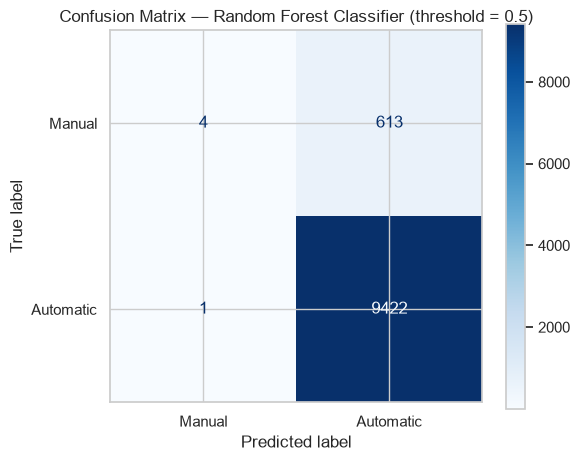

True Negatives (correct 'manual'):    4
False Positives (manual -> predicted automatic): 613
False Negatives (automatic -> predicted manual): 1
True Positives (correct 'automatic'): 9422


In [23]:
confusion_matrix_values = confusion_matrix(target_classification, oof_predicted_labels)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix_values, display_labels=["Manual", "Automatic"]
).plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title(f"Confusion Matrix — {best_classifier_name} (threshold = 0.5)")
plt.show()

true_negatives, false_positives, false_negatives, true_positives = confusion_matrix_values.ravel()
print(f"True Negatives (correct 'manual'):    {true_negatives}")
print(f"False Positives (manual -> predicted automatic): {false_positives}")
print(f"False Negatives (automatic -> predicted manual): {false_negatives}")
print(f"True Positives (correct 'automatic'): {true_positives}")


*(Address here: which error type — FP or FN — is more critical in this context and why? In which
feature regions does the model fail systematically? What insights emerge from the matrix?)*


### 8.2 Probability-Based Analysis

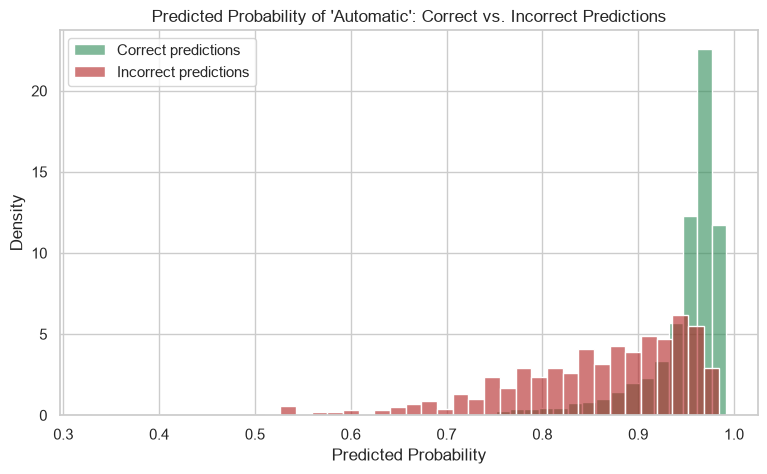

In [24]:
correct_prediction_mask = oof_predicted_labels == target_classification.values

plt.figure(figsize=(9, 5))
sns.histplot(oof_predicted_probabilities[correct_prediction_mask], bins=40, color="seagreen",
             label="Correct predictions", stat="density", alpha=0.6)
sns.histplot(oof_predicted_probabilities[~correct_prediction_mask], bins=40, color="firebrick",
             label="Incorrect predictions", stat="density", alpha=0.6)
plt.title("Predicted Probability of 'Automatic': Correct vs. Incorrect Predictions")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend()
plt.show()


### 8.3 Error as a Function of Features

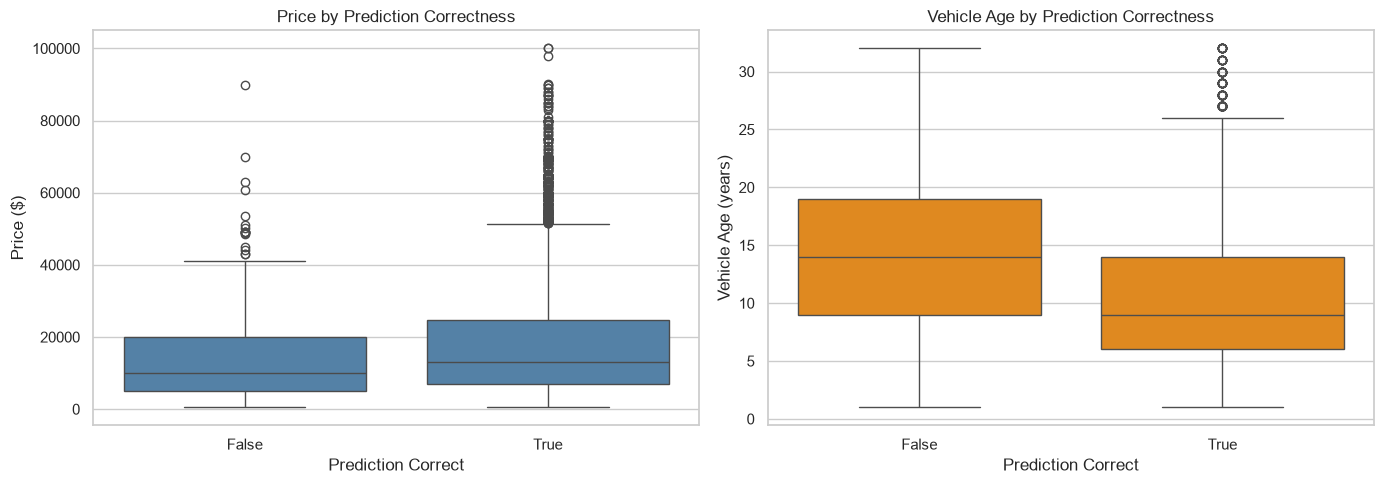

In [25]:
classification_error_df = used_cars_classification.assign(
    predicted_probability=oof_predicted_probabilities,
    is_correct=correct_prediction_mask,
)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=classification_error_df, x="is_correct", y="price", ax=axes[0], color="steelblue")
axes[0].set_title("Price by Prediction Correctness")
axes[0].set_xlabel("Prediction Correct")
axes[0].set_ylabel("Price ($)")

sns.boxplot(data=classification_error_df, x="is_correct", y="vehicle_age", ax=axes[1], color="darkorange")
axes[1].set_title("Vehicle Age by Prediction Correctness")
axes[1].set_xlabel("Prediction Correct")
axes[1].set_ylabel("Vehicle Age (years)")
plt.tight_layout()
plt.show()


### 8.4 Threshold Sensitivity Analysis

In [26]:
thresholds = np.round(np.arange(0.1, 1.0, 0.1), 1)
threshold_metrics = []

for threshold in thresholds:
    predicted_labels_at_threshold = (oof_predicted_probabilities >= threshold).astype(int)
    threshold_metrics.append({
        "threshold": threshold,
        "precision": precision_score(target_classification, predicted_labels_at_threshold, zero_division=0),
        "recall": recall_score(target_classification, predicted_labels_at_threshold, zero_division=0),
        "f1": f1_score(target_classification, predicted_labels_at_threshold, zero_division=0),
        "mcc": matthews_corrcoef(target_classification, predicted_labels_at_threshold),
    })

threshold_metrics_df = pd.DataFrame(threshold_metrics)
threshold_metrics_df


,threshold,precision,recall,f1,mcc
0,0.1,0.938546,1.000000,0.968299,0.000000
1,0.2,0.938546,1.000000,0.968299,0.000000
2,0.3,0.938546,1.000000,0.968299,0.000000
3,0.4,0.938727,0.999894,0.968345,0.043568
4,0.5,0.938914,0.999894,0.968445,0.068644
5,0.6,0.940114,0.999576,0.968933,0.142605
6,0.7,0.942530,0.995543,0.968311,0.177436
7,0.8,0.952238,0.973257,0.962633,0.276649
8,0.9,0.971042,0.875411,0.920750,0.317281


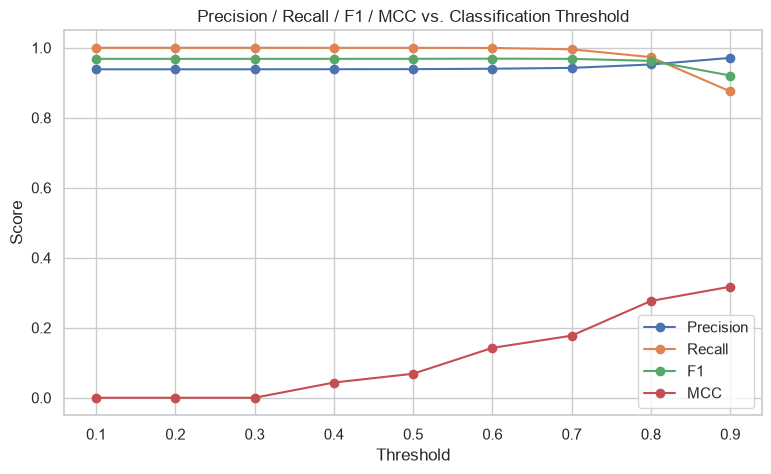

In [27]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_metrics_df["threshold"], threshold_metrics_df["precision"], marker="o", label="Precision")
plt.plot(threshold_metrics_df["threshold"], threshold_metrics_df["recall"], marker="o", label="Recall")
plt.plot(threshold_metrics_df["threshold"], threshold_metrics_df["f1"], marker="o", label="F1")
plt.plot(threshold_metrics_df["threshold"], threshold_metrics_df["mcc"], marker="o", label="MCC")
plt.title("Precision / Recall / F1 / MCC vs. Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()


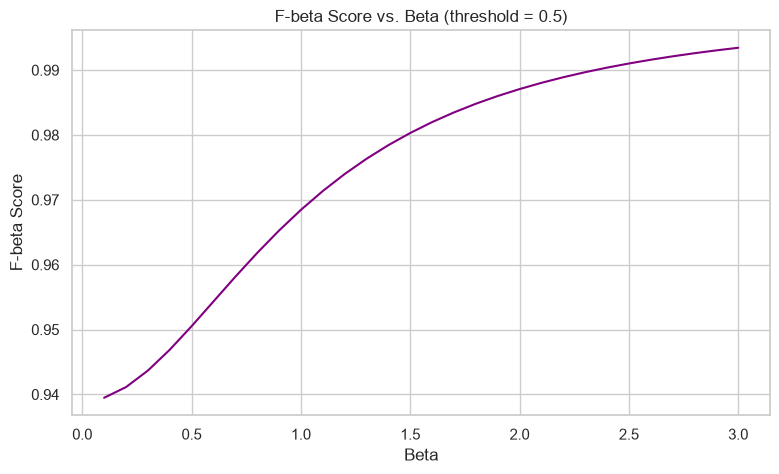

In [28]:
beta_values = np.linspace(0.1, 3.0, 30)
fixed_threshold = 0.5
predicted_labels_fixed_threshold = (oof_predicted_probabilities >= fixed_threshold).astype(int)
f_beta_scores = [
    fbeta_score(target_classification, predicted_labels_fixed_threshold, beta=beta, zero_division=0)
    for beta in beta_values
]

plt.figure(figsize=(9, 5))
plt.plot(beta_values, f_beta_scores, color="purple")
plt.title(f"F-beta Score vs. Beta (threshold = {fixed_threshold})")
plt.xlabel("Beta")
plt.ylabel("F-beta Score")
plt.show()


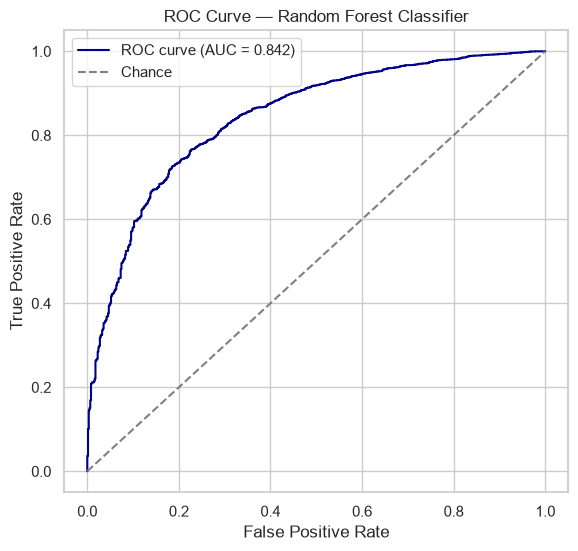

In [29]:
false_positive_rate, true_positive_rate, _ = roc_curve(target_classification, oof_predicted_probabilities)
auc_roc_score = roc_auc_score(target_classification, oof_predicted_probabilities)

plt.figure(figsize=(6.5, 6))
plt.plot(false_positive_rate, true_positive_rate, label=f"ROC curve (AUC = {auc_roc_score:.3f})", color="darkblue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.title(f"ROC Curve — {best_classifier_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


*(Address here: the trade-off between false positives and false negatives across thresholds; which
threshold range looks stable vs. unstable for this problem?)*

### Discussion

*(Free space for your Part 3 write-up — critical comparison of the evaluated classification models,
integrating insights from both the modeling and error-analysis stages: strengths/limitations
relative to the data, key failure modes, the relationship between model assumptions and observed
performance, most significant insights, and concrete recommendations for future improvement.)*


## Final Reflection

*(1. Where does the model fail most? 2. Are failures due to data, model, or problem formulation?
3. What improvements would you propose? 4. What insights did you gain from this analysis?)*
